## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

## Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
visa = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EasyVisa.csv')

In [ ]:
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
data.shape

(25480, 12)

#### Check the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

No duplicate values.

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


No missing values in dataset.

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
data.describe(include='all')

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480.000000,25480.000000,25480,25480.000000,25480,25480,25480
unique,25480,6,4,2,2,NaN,NaN,5,NaN,4,2,2
top,EZYV25480,Asia,Bachelor's,Y,N,NaN,NaN,Northeast,NaN,Year,Y,Certified
freq,1,16861,10234,14802,22525,NaN,NaN,7195,NaN,22962,22773,17018
mean,NaN,NaN,NaN,NaN,NaN,5667.043210,1979.409929,NaN,74455.814592,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22877.928848,42.366929,NaN,52815.942327,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,-26.000000,1800.000000,NaN,2.136700,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1022.000000,1976.000000,NaN,34015.480000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2109.000000,1997.000000,NaN,70308.210000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3504.000000,2005.000000,NaN,107735.512500,NaN,NaN,NaN


#### Fixing the negative values in number of employees columns

In [ ]:
#To check for negative values in the no_of_employees column
negative_values = data[data["no_of_employees"] < 0]
negative_values.shape


(33, 12)

In [ ]:
data["no_of_employees"] = data["no_of_employees"].abs()
negative_values = data[data["no_of_employees"] < 0]
negative_values.shape

(0, 12)

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [ ]:
# checking the number of unique values for case_id
data["case_id"].nunique()

25480

In [ ]:
#Case_id is dropped because it is unique for all the rows and does not bear any significance for the model.
data.drop(["case_id"], axis=1, inplace=True)

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

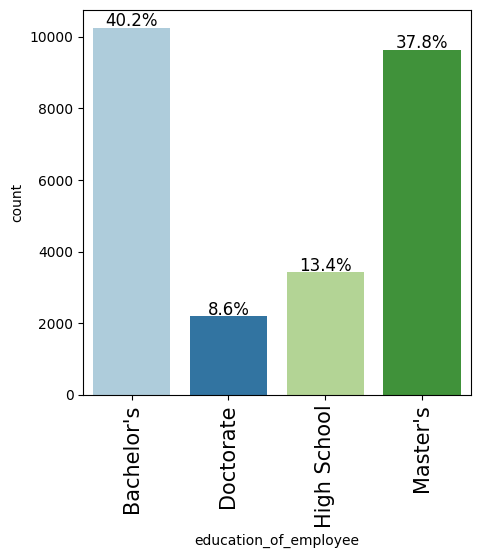

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)

1) At bachelor's level 40.2% student apply  for visa which is max.

2) At Doctorate level only 8.6% which is  low compared to other.

So, need to increase doctorate level by  focussing on this education.

#### Observations on region of employment

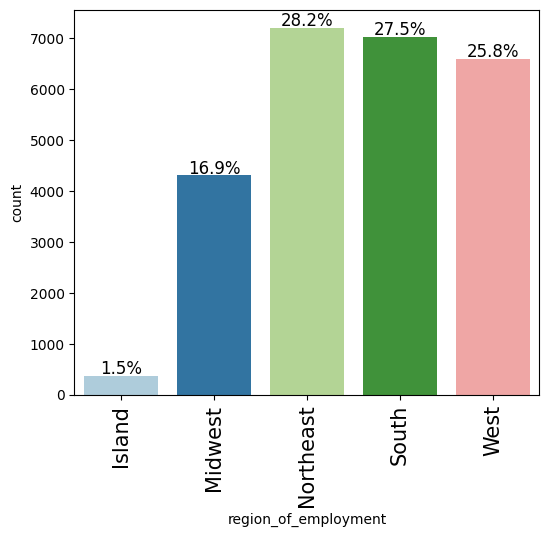

In [ ]:
labeled_barplot(data, "region_of_employment", perc=True)

1) Northeast region has more employment compared to others.

2) Island region has low employment rate  

I recommended that need is to focus on Island region employment to overcome  this issue.

#### Observations on job experience

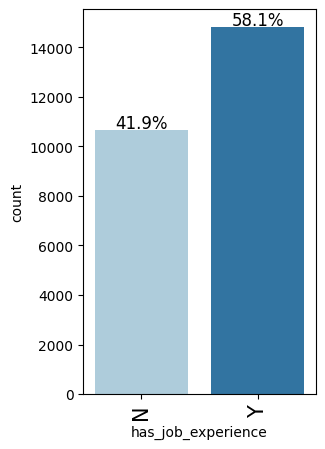

In [ ]:
labeled_barplot(data, "has_job_experience", perc=True)

1) Majority of people applying for visa have job experience. So, this plays a important rile in visa certification.

#### Observations on case status

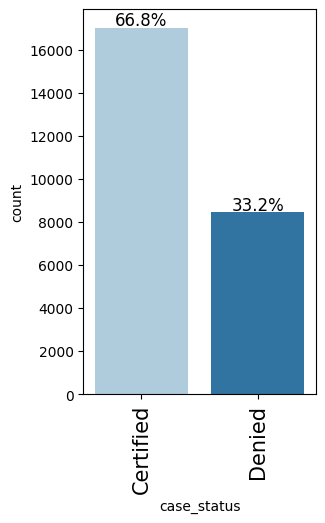

In [ ]:
labeled_barplot(data, "case_status", perc=True)

**Class Imbalance:** There is a significant class imbalance in the "case_status" variable. A large majority of the applications are certified (approved), while a smaller proportion are denied.

**High Certification Rate:** This indicates a relatively high success rate for visa applications. It suggests that a substantial portion of applicants meet the required criteria for visa certification.

### Bivariate Analysis

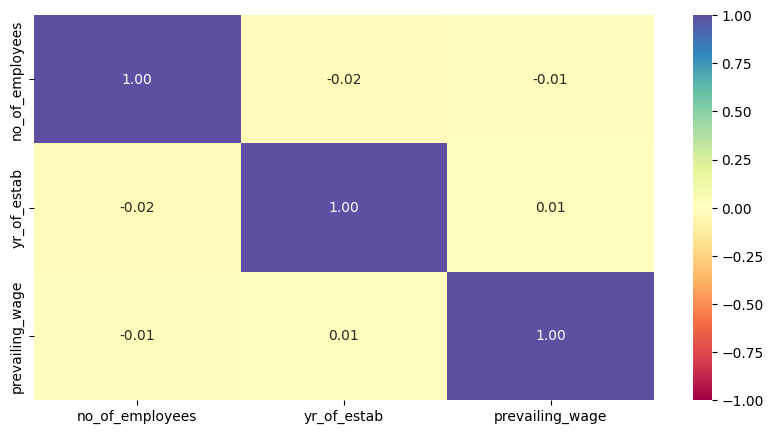

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

1) There is a positive correlation between Year in which the employer's company was established and prevailing wages which mean old companies are paying better wages.

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


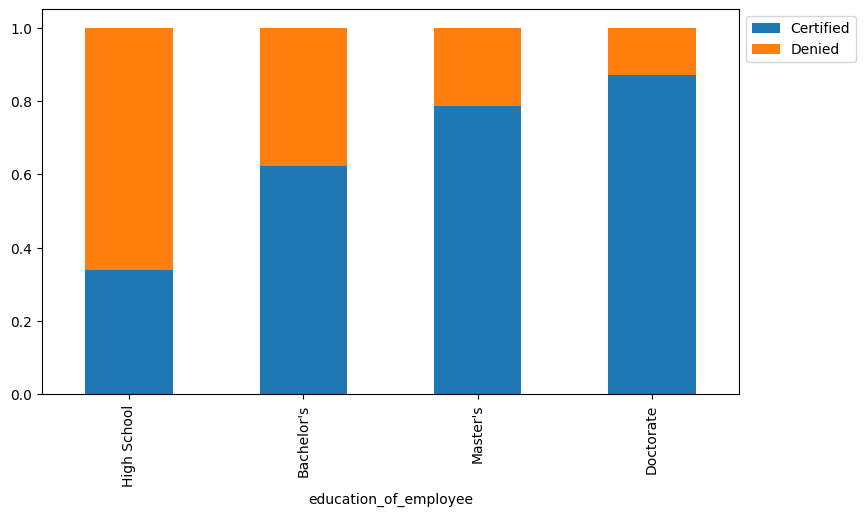

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

1) Higher the education like Master's amd Doctorate degress, the visa certification is higher.

2) Visa denials are higher for High School diplomas.

#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


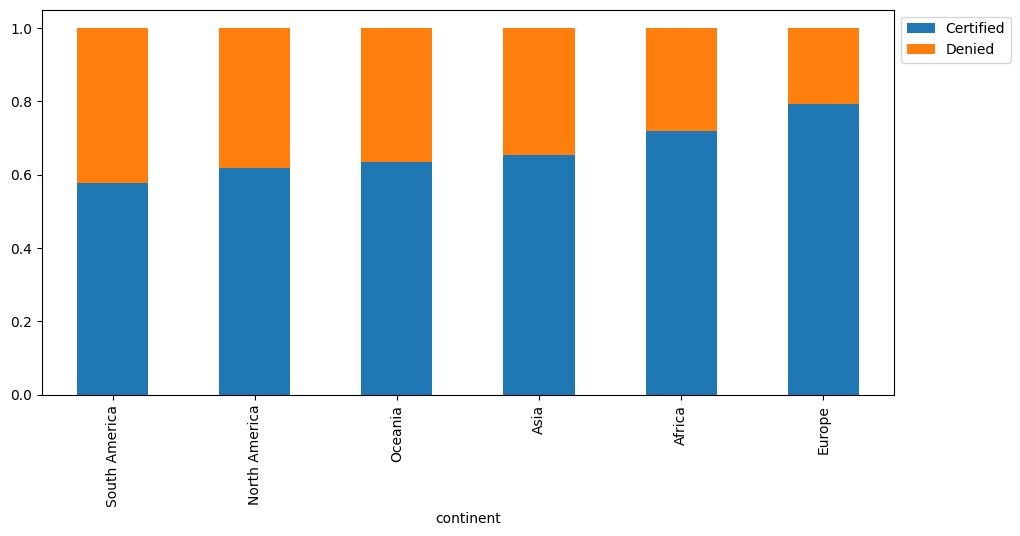

In [ ]:
stacked_barplot(data, "continent", "case_status")

1) Highest number of visa applicants are form Asia followed by North america and Europe.

2) South America, Africa and Oceania have high number of denied visa cases based on overall number of application.

#### Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Let's see if having work experience has any influence over visa certification

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


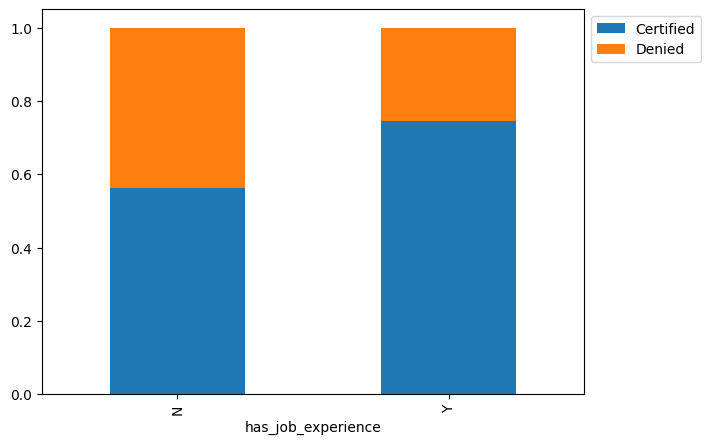

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status")

1) Candidates who have more job experience are having less rejection rate for visas which mean s it is an important factor for visa certification.

#### Checking if the prevailing wage is similar across all the regions of the US

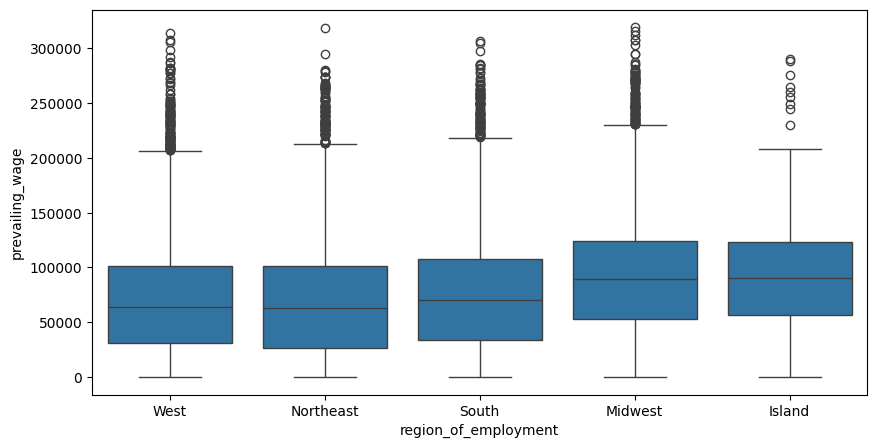

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()

1) West region has slightly higher wages compared to the others, but overall, the median wages across regions appear fairly similar. The presence of numerous outliers suggests that some individuals earn significantly more than the majority within each region.


#### The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage

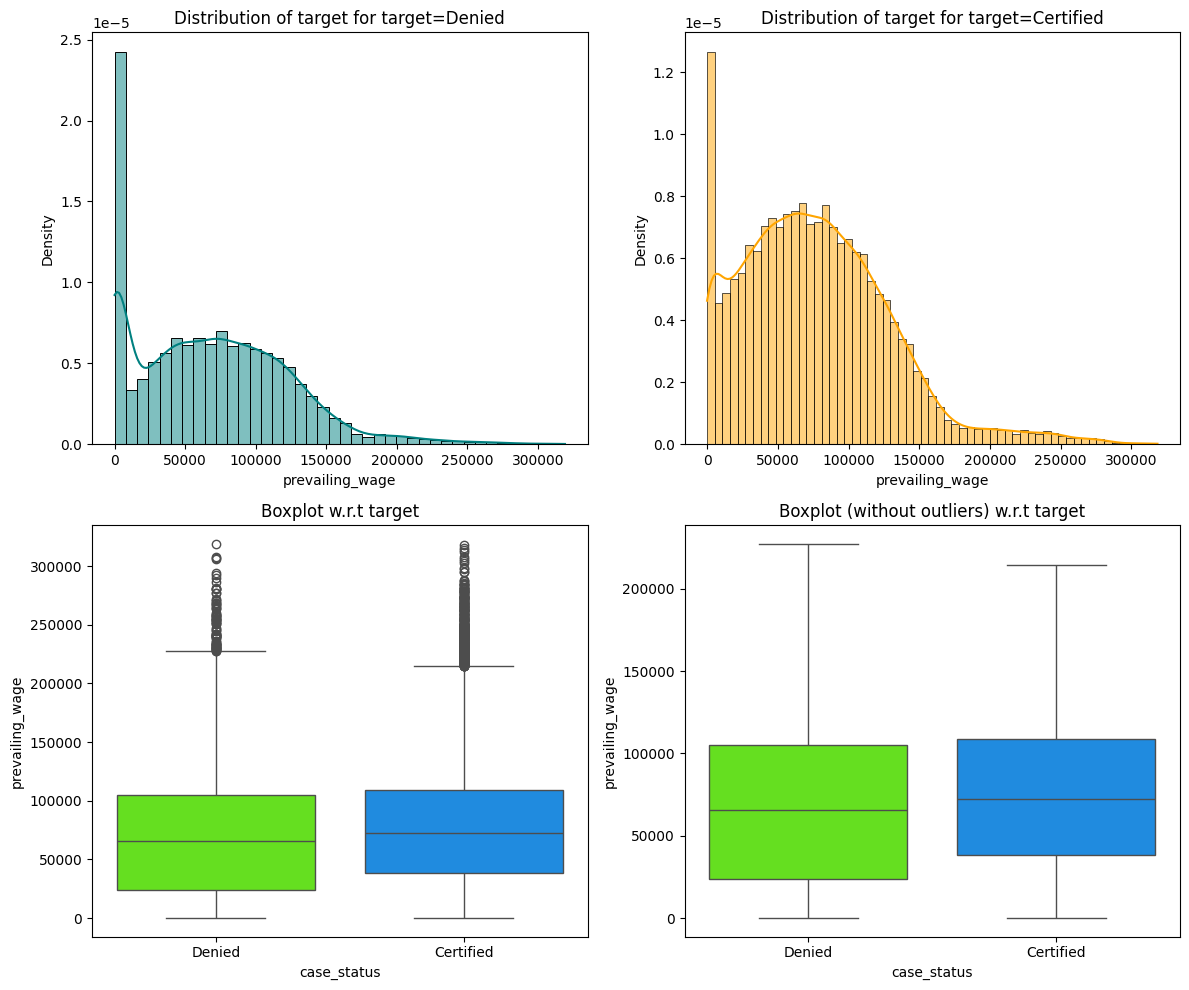

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

1) These show the distribution of wages for both Certified and Denied cases. The highest densities are at lower wage values, with Denied cases showing a slightly higher peak.

2) The median prevailing wage is higher for certified cases thus it is an important factor in visa approvals for the candidates.

#### The prevailing wage has different units (Hourly, Weekly, etc). Let's find out if it has any impact on visa applications getting certified.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


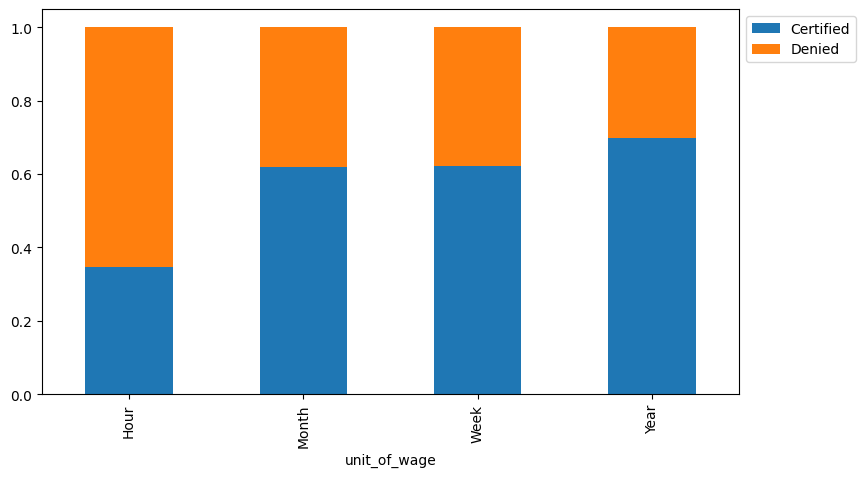

In [ ]:
stacked_barplot(data, "unit_of_wage", "case_status")

1) Vast majority of applications being based on annual salaries and also certified rates are higher.

2) Hourly wage applications have a higher denial rate compared to others—more applications were denied than certified.


## Data Pre-processing

### Outlier Check

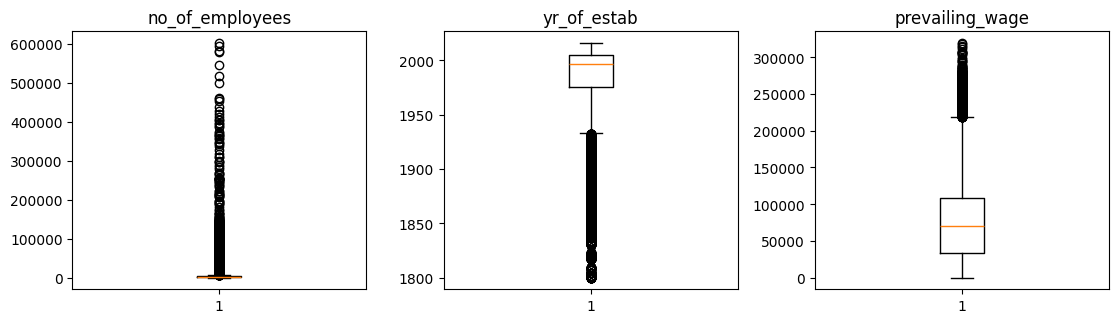

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Number of Employees (no_of_employees)**- The distribution suggests most companies have a relatively small number of employees. There are numerous outliers, with some companies reaching up to 600,000 employees.

**Year of Establishment (yr_of_estab)**- Most businesses were founded between 1950 and 2000, with a strong concentration in this range.There are outliers representing companies established as early as the 1800s.

**Prevailing Wage (prevailing_wage)**- Most wages fall between 0 and 100,000, forming the core distribution.There are several high-wage outliers, reaching up to 300,000.

**Key Takeaways:**
1) The dataset contains significant variation in company sizes, establishment years, and wages.

2) The presence of outliers in all three distributions suggests the dataset includes extreme values, whether it's unusually large corporations, very old establishments, or exceptionally high wages.


### Data Preparation for modeling

In [ ]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(["case_status"], axis=1)
y = data["case_status"]

X = pd.get_dummies(X, drop_first=True)

# Split the dataset into train and valid with a ratio of 7:3
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Split the dataset into valid and test with a ratio of 9:1
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.1, random_state=1, stratify=y_val
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

The OFLC wants to automate the visa application process to make it more efficient. They are particularly interested in identifying the applicants with the highest chances of approval and reduce manual intervention.

A false negative in this scenario means predicting that an applicant will be denied when they would have actually been approved. This is a costly mistake for both the applicant and the employer. **Recall** focuses on minimizing these false negatives.

**Imbalance Data**: Based on the data profiling of case_status it seems the target class is imbalanced towards visa certification.To mitigate the challenges posed by class imbalance we will incorporate the following techniques:

**Oversampling:** Generating synthetic samples for the minority class to balance the dataset.

**Undersampling:** Removing samples from the majority class to reduce the imbalance.

**Using appropriate evaluation metrics:** Focusing on metrics like recall, precision, and F1-score, which are less sensitive to class imbalance compared to accuracy.

**Focus on Certification:** The objective is to identify applicants with a high chance of getting their visas certified. So, we will focus on **recall**, which focuses on minimizing false negatives (incorrectly denying visas to qualified candidates).

**Efficiency:** By identifying most applicants who would get certified (high recall), the OFLC can focus their resources on reviewing only a small subset of applications. This directly improves efficiency and reduces manual effort.

**Compliance:** By focusing on recall, it helps ensure that most of the qualified applicants who deserve a visa get certified.

In [ ]:
# Compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

#### Defining scorer to be used for cross-validation and hyperparameter tuning

As mentioned in Model Evaluation Criterion we will be using **Recall Score** and the scoring metric.

In [ ]:
scorer = metrics.make_scorer(metrics.recall_score)

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting the number of splits to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)  # Fitting the model on X_train and y_train
    scores = recall_score(y_val, model.predict(X_val))  # Using recall_score as the metric
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.7751203687750448
Random forest: 0.8387487214396122
GBM: 0.8727446688039722
Adaboost: 0.889449723112179
Xgboost: 0.8504155343281352
dtree: 0.739527537803635

Validation Performance:

Bagging: 0.7638223770134959
Random forest: 0.8289072703526339
GBM: 0.8746190683500218
Adaboost: 0.8831084022638224
Xgboost: 0.8493687418371789
dtree: 0.7414018284719199


**AdaBoost,GBM and XGBoost are the top performers:** AdaBoost, Gradient Boosting Machine (GBM), XGBoost models show the highest cross-validation and validation scores, indicating strong predictive performance.

**Random Forest also performs well:** Random Forest achieves good results, slightly behind AdaBoost and GBM.

**Bagging and Decision Tree have lower scores:** Bagging and Decision Tree models have comparatively lower scores, suggesting they may not be as effective for this particular problem.

**Consistent performance across training and validation:** Most models exhibit consistent performance between cross-validation on the training dataset and validation performance. This suggests that the models are not significantly overfitting to the training data.

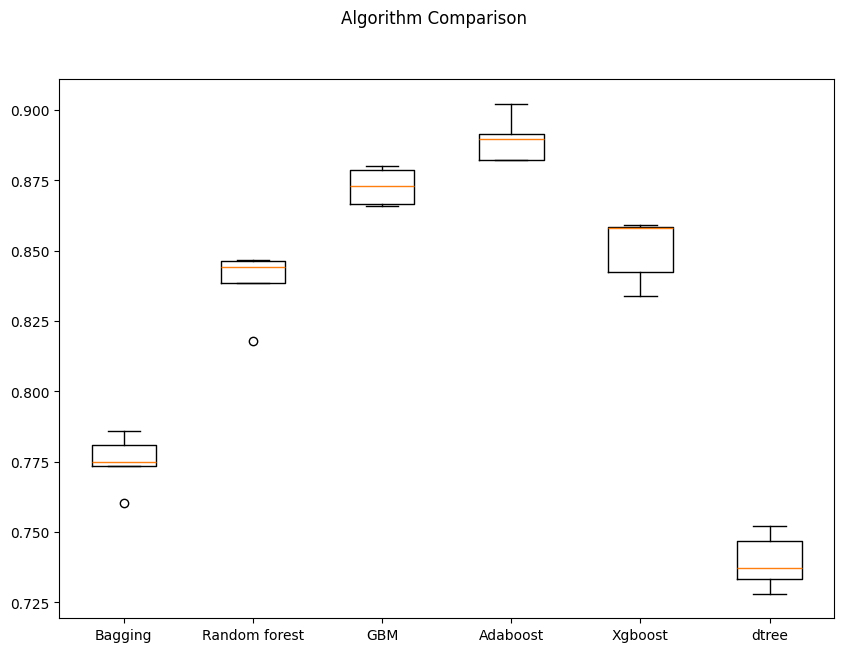

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with oversampled data

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting the number of splits to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  # Fitting on oversampled data
    scores = recall_score(y_val, model.predict(X_val))  # Using recall_score
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.7438098298435637
Random forest: 0.8191058057828453
GBM: 0.8592301753992826
Adaboost: 0.8699735003715444
Xgboost: 0.8440353638440211
dtree: 0.7188782986681831

Validation Performance:

Bagging: 0.7485851110143665
Random forest: 0.8186765346103614
GBM: 0.8528515454941228
Adaboost: 0.8730953417501088
Xgboost: 0.8410970831519373
dtree: 0.7248585111014366


**Observations after OverSampling**

a) **AdaBoost and GBM** emerge as the top performing models for this classification task due to their consistently high scores.

b) **Random Forest and XGBoost** are also viable options with slightly lower performance but still demonstrate good predictive capabilities.

c) **Bagging and Decision Tree models** may require further investigation or improvement to achieve comparable performance.

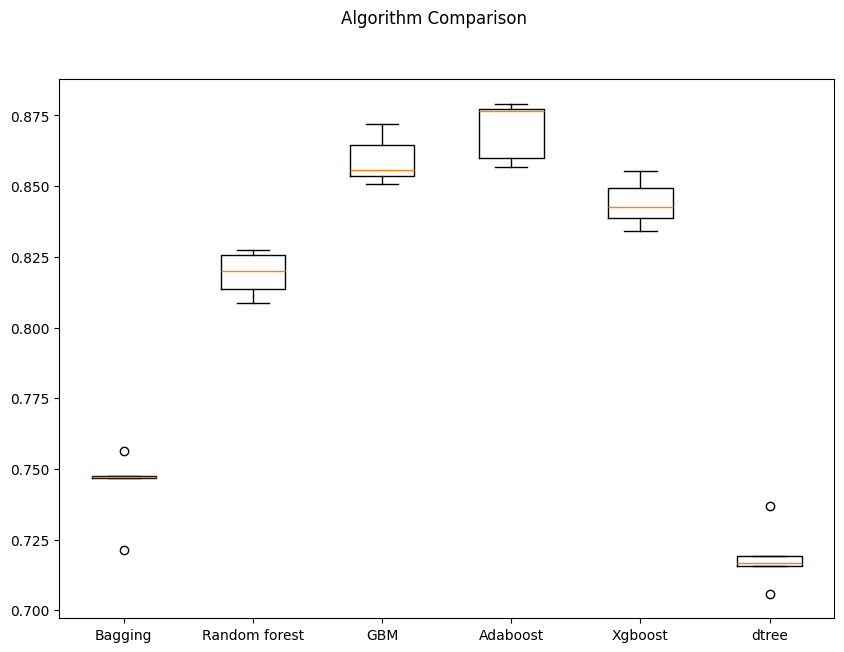

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with undersampled data

In [ ]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting the number of splits to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold, n_jobs=-1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)  # Fitting on undersampled data
    scores = recall_score(y_val, model.predict(X_val))  # Using recall_score
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.6040899760520013
Random forest: 0.6831018360132285
GBM: 0.7187274774774776
Adaboost: 0.7094403580795986
Xgboost: 0.6966116432888584
dtree: 0.6177627152468925

Validation Performance:

Bagging: 0.6055724858511101
Random forest: 0.6702220287331302
GBM: 0.7085328689595124
Adaboost: 0.716804527644754
Xgboost: 0.6852416195037004
dtree: 0.6216804527644754


Based on above results, **using undersampled data** seems to result in a decrease in overall model performance. While GBM and AdaBoost still exhibit relatively better performance compared to other models, the overall scores are lower compared to those achieved with original or oversampled data.

**GBM and AdaBoost may still be preferable** compared to other models, but further exploration with hyperparameter tuning need to be explored.

The **reduction in training data due to undersampling** likely affecting the models' ability to learn complex patterns and generalize effectively.

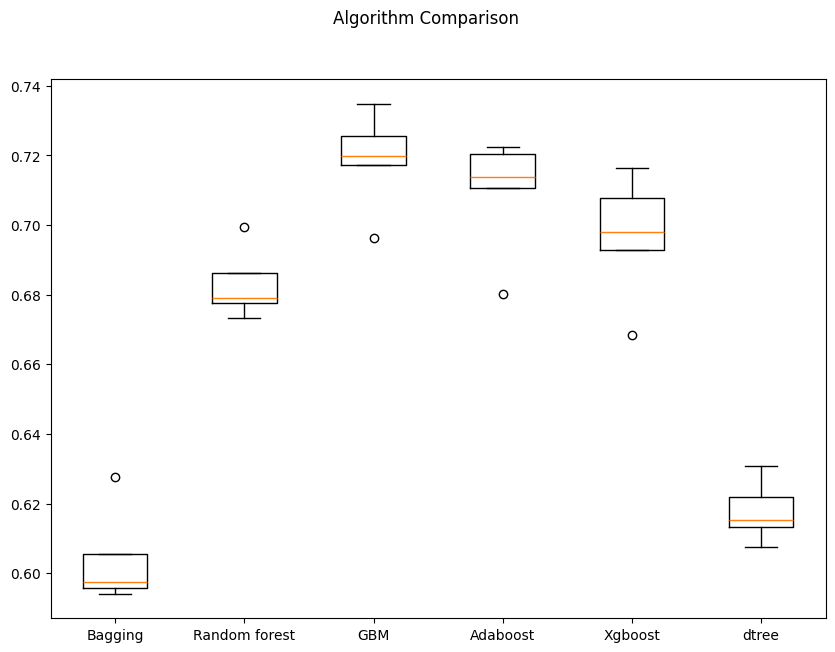

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

## Hyperparameter Tuning

Here the approach is to do **Hyperparameter tuning of AdaBoost, GBM, XgBoost with oversampled data and also explore the tuning of Random Forest with undersampled data.**

### Tuning AdaBoost using oversampled data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.1, 0.2, 0.3, 0.4, 0.5],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1)],
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=5,  # Setting cv to 5
    random_state=1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)  # Fitting on oversampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9088380718023306:


In [53]:
# Tuning the best model with best hypertuned parameters
tuned_ada = AdaBoostClassifier(
    n_estimators= 100, learning_rate= 0.1, estimator= DecisionTreeClassifier(max_depth=1, random_state=1)
)

tuned_ada.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=100)

In [54]:
## Check the model performance for Train data
ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.702804,0.911357,0.643111,0.754089


In [55]:
## Check the model performance for validation data.
ada_val_perf = model_performance_classification_sklearn(tuned_ada,X_val, y_val)
ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.716529,0.909229,0.731524,0.810753


### Tuning Random forest using undersampled data

In [ ]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "min_samples_leaf": np.arange(1, 10),
    "max_features": [np.arange(0.1, 1.0, 0.1),'sqrt'],
    "max_samples": np.arange(0.1, 1.0, 0.1)}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)  # Fitting on undersampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': 500, 'min_samples_leaf': np.int64(6), 'max_samples': np.float64(0.1), 'max_features': 'sqrt'} with CV score=0.7514796442011631:
CPU times: user 6.32 s, sys: 766 ms, total: 7.09 s
Wall time: 4min 53s


In [ ]:
## Tuning the best model with best hypertuned parameters
tuned_rf2 = RandomForestClassifier(
    max_features='sqrt',
    random_state=1,
    max_samples=0.1,
    n_estimators=500,
    min_samples_leaf=6,
)

tuned_rf2.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.1, min_samples_leaf=6, n_estimators=500,
                       random_state=1)

In [ ]:
## Check the model performance for Train data
rf2_train_perf = model_performance_classification_sklearn(
    tuned_rf2, X_train_un, y_train_un
)
rf2_train_perf

,Accuracy,Recall,Precision,F1
0,0.725477,0.76988,0.707086,0.737148


In [ ]:
## Check the model performance for validation data.
rf2_val_perf = model_performance_classification_sklearn(tuned_rf2,X_val,y_val)
rf2_val_perf

,Accuracy,Recall,Precision,F1
0,0.714929,0.749238,0.809692,0.778293


### Tuning with Gradient boosting with oversampled data

In [ ]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": np.arange(100, 500, 50),
    "learning_rate": [0.1, 0.2, 0.3, 0.4, 0.5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "max_features": ['sqrt', 0.5, 0.7, 0.9],
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    scoring=scorer,
    n_iter=50,
    n_jobs=-1,
    cv=5,  # Setting cv to 5
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)  # Fitting on oversampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.1} with CV score=0.8573772097557812:
CPU times: user 16.6 s, sys: 2.73 s, total: 19.4 s
Wall time: 20min 17s


In [ ]:
## Tuning the best model with best hypertuned parameters
tuned_gbm = GradientBoostingClassifier(
    max_features=0.7,
    random_state=1,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.9
)

tuned_gbm.fit(X_train_over, y_train_over)

GradientBoostingClassifier(max_features=0.7, random_state=1, subsample=0.9)

In [ ]:
## Check the model performance for Train data
gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.797616,0.856208,0.766399,0.808818


In [ ]:
## Check the model performance for Train data
gbm_val_perf = model_performance_classification_sklearn(tuned_gbm,X_val,y_val)
gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.734554,0.845886,0.776579,0.809752


### Tuning XGBoost using oversampled data

In [60]:
%%time

# defining model
Model = XGBClassifier(random_state=1, eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'scale_pos_weight': [1, 2, 3, 4, 5],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=5,  # Setting cv to 5
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)  # Fitting on oversampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'subsample': 1.0, 'scale_pos_weight': 4, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 0.1} with CV score=0.9700311434936735:
CPU times: user 3.65 s, sys: 417 ms, total: 4.06 s
Wall time: 3min 28s


In [61]:
# Tuning the best model with best hypertuned parameters
xgb2 = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=1.0,
    scale_pos_weight=4,
    n_estimators=200,
    learning_rate=0.1,
    gamma=0.1,
)

xgb2.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [62]:
## Check the model performance for Train data
xgb2_train_perf = model_performance_classification_sklearn(
    xgb2, X_train_over, y_train_over
)
xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.787417,0.995047,0.703084,0.823967


In [63]:
## Check the model performance for validation data
xgb2_val_perf = model_performance_classification_sklearn(xgb2,X_val,y_val)
xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.706062,0.974097,0.701631,0.815713


## Model Performances

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        ada_train_perf.T,
        rf2_train_perf.T,
        gbm_train_perf.T,
        xgb2_train_perf.T,

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",

]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data
Accuracy,0.702804,0.725477,0.797616,0.787417
Recall,0.911357,0.769880,0.856208,0.995047
Precision,0.643111,0.707086,0.766399,0.703084
F1,0.754089,0.737148,0.808818,0.823967


**Based on the training performance comparison**

a) **XGBoost (with oversampling)** seems to be the best performer as maximizing recall is our primary goal. However, it comes with a lower precision, indicating potential false positives.

b) **Gradient Boosting (with oversampling) offers a good balance between recall and precision, leading to a high F1-score.**

c) **AdaBoost (with oversampling) also shows high recall but with lower precision.**

d) **Random Forest (with undersampling)** demonstrates moderate performance across all metrics.

In [ ]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        ada_val_perf.T,
        rf2_val_perf.T,
        gbm_val_perf.T,
        xgb2_val_perf.T,

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data
Accuracy,0.716529,0.714929,0.734554,0.706062
Recall,0.909229,0.749238,0.845886,0.974097
Precision,0.731524,0.809692,0.776579,0.701631
F1,0.810753,0.778293,0.809752,0.815713


**Based on the validation performance comparison:**

a) **AdaBoost (with oversampling)** is maintaining a high recall and showing improved precision on validation data.

b) Gradient Boosting (with oversampling) remains a strong contender with consistent and balanced performance.

c) **XGBoost (with oversampling)** still achieves high recall but with lower precision.

d) **Random Forest (with undersampling)** shows lower overall performance.

**Key Takeaways:**

a) **AdaBoost** **is recommended as the top model due to its high recall and improved precision on validation data.**

b) **XGBoost** **lower precision might be a concern despite its high recall**.

c) **Gradient Boosting** remains a viable option with consistent and balanced performance.

d) **Random Forest** does not give good performance.

e) **Oversampling continues to be a beneficial strategy** for improving model performance, particularly recall.

The validation performance confirms the models' generalizability and ability to perform well on unseen data.

In [56]:
## Based on Train and Validation results AdaBoost tuned with oversampled data has been chosen and print model performance on the test data.
test = model_performance_classification_sklearn(tuned_ada, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.732026,0.915851,0.742857,0.820333


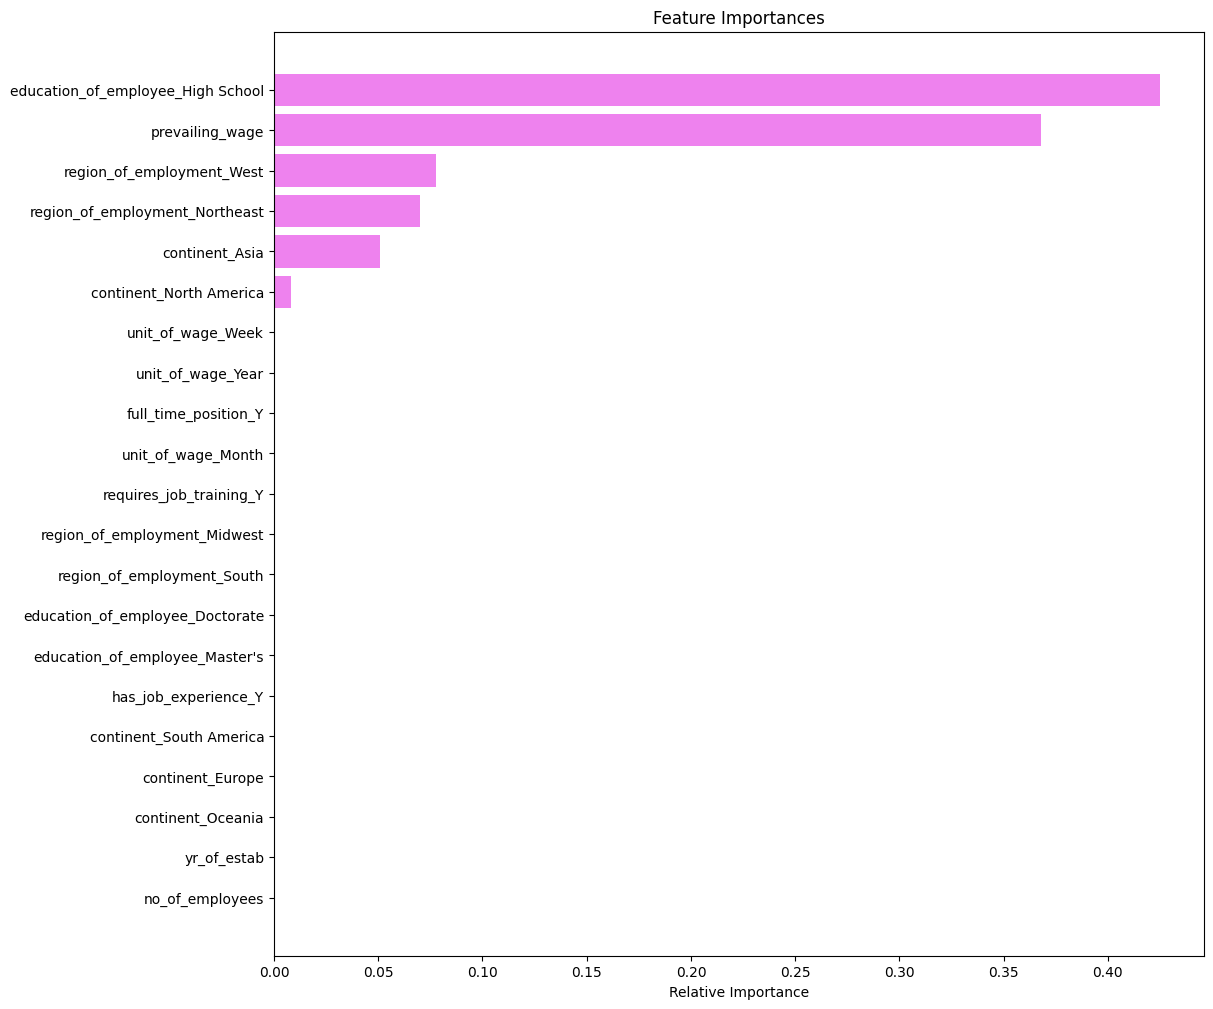

In [57]:
## Print the feature importances from the best model Adaboost Tuned with OverSampled Data.
feature_names = X_train.columns
importances = tuned_ada.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Observations:**

1) The top features affecting visa approval **High School education followed by Prevailing wages and regions of Northeast and West.**

2) **Other Factors:**- Features related to continent, unit of wage, full-time position, job training, experience, and company size all have low importance implying they have little impact.


## Actionable Insights and Recommendations

**Key Insights:**

1) **Education Level Matters**:- High School education is the most influential feature, with an importance of ~0.40. Doctorate and Master’s degrees rank much lower, suggesting they have less impact on the outcome. We need to recognize the importance of education and job experience in the visa approval process. Applicants with higher education levels and prior job experience tend to have higher chances of certification.

2) **Prevailing Wage is Critical:**- This feature has an importance of ~0.35, meaning it significantly affects the model's predictions. Understanding the regional variations in prevailing wages will ensure fair compensation for foreign workers and protect local talent. This information can inform decision-making regarding visa applications and potential wage adjustments.

3) **Regional Effects:**- The West and Northeast regions have notable importance (~0.15 and ~0.10 respectively), suggesting location plays a role in the outcome.The South and Midwest regions are minimal contributers.

5) **Other Factors:**- Features related to continent, unit of wage, full-time position, job training, experience, and company size all have low importance implying they have little impact.

6) **Work category & job title:** Specific roles may be more favorable based on industry demand.



**Business Recomendations**

1) Implement the developed machine learning model within OFLC's system to prioritize visa applications for review. This will help reduce manual effort and expedite the approval process for qualified candidates.

2) Create profiles of applicants who are more likely to be certified based on Education level, Prevailing Wage, Region. This can be used as a guide for OFLC officers to quickly identify and prioritize applications with a higher likelihood of approval.

3) Regularly monitor prevailing wage levels across different regions to ensure fair compensation for foreign workers and protect local talent.

4) Encourage employers to provide detailed information about the skills required for the positions they are seeking to fill. This will allow OFLC to prioritize applications for jobs with critical skill shortages.

5) Continuously monitor the performance of the implemented solutions and identify areas for further improvement. This will ensure that the visa approval process remains efficient and effective in meeting the needs of the workforce.

<font size=6 color='blue'>Power Ahead</font>
___